In [ ]:
pip install -r requirements.txt

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from cheb_ar import *

Devices: [CudaDevice(id=0)]


In [ ]:
# ---------------- parameters (same as your snippet) ----------------
w_a = 25.338776456203686
w_b = 2 * w_a
kappa_b = 5 / 10.4
E_J = 37 * 2 * np.pi
phi_a, phi_b = 0.11, 0.204
epsilon_p = 0.1
g  = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b
kappa_2 = 4 * g**2 / kappa_b
kappa_1 = 0.005 * kappa_2
n_a, n_b = 25, 11
dims = (n_a, n_b)
alpha_sq = 8.5
epsilon_d = 2 * alpha_sq * g2

N = n_a * n_b
T_block = 2 * jnp.pi / w_a
tsave = jnp.array([0.0, T_block])
method = dq.method.Tsit5(rtol=1e-9, atol=1e-10)
opts = dq.Options(assume_hermitian=False)

# Warm start

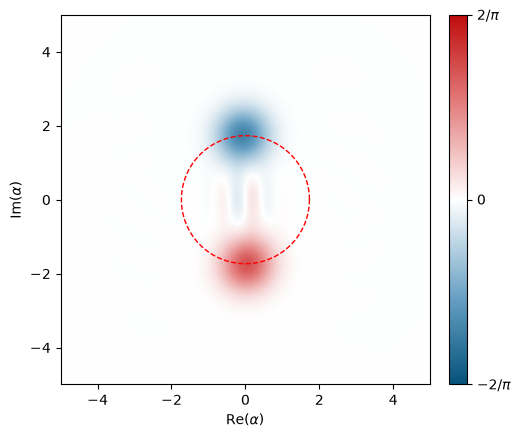

In [18]:
import json
def _from_jsonable(obj):
    """Recursively convert JSON types back to numpy/complex objects.
    
    ``{"real": ..., "imag": ...}`` dicts become complex numbers;
    lists become numpy arrays if they contain numeric/complex values.
    """
    if isinstance(obj, dict):
        # Complex number encoding
        if set(obj.keys()) == {"real", "imag"}:
            return complex(obj["real"], obj["imag"])
        # Regular dict: recurse on values
        return {k: _from_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        converted = [_from_jsonable(v) for v in obj]
        # Convert to numpy array if all elements are numeric or complex
        if all(isinstance(v, (int, float, complex, np.ndarray)) for v in converted):
            return np.array(converted)
        return converted
    return obj  # int, float, str → keep as-is


def load_json(path):
    """Load a JSON file and return a dict with numpy/complex values."""
    with open(path, "r") as f:
        raw = json.load(f)
    return _from_jsonable(raw)

data = load_json("/home/tmalasda/output/Cheb_Ar/13_07_2026/cheb_ar_vs_epsp_alphasq_6.json")[0]
x_ritz_warm  = data["x_ritz"]

rho_ritz_warm = dq.unvectorize(dq.asqarray(x_ritz_warm[:, None]))
rho_ritz_warm = dq.asqarray(dq.to_jax(rho_ritz_warm), dims=(n_a, n_b))
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz_warm,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

# Cheb-Ar

In [19]:
def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

In [20]:
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)


In [21]:
params['g2']/2/np.pi*1e3

np.float64(13.546076145275608)

In [22]:
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)

In [23]:
x0 = x_ritz_warm#solver.make_x0(seed=0)
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)

|██████████| 100.0% ◆ elapsed 165.81ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 188.62ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 223.63ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 283.32ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 312.67ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 386.65ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 424.87ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 445.79ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 438.48ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 440.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 433.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 426.36ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 425.95ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 425.75ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 420.11ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 416.17ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 414.36ms ◆ r

In [24]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.0795662449429857-1.6219319811956603e-13j),
 'semi_re': np.float64(0.9154296568156806),
 'semi_im': np.complex128(0.8532050036134811-9.71943480246939e-15j),
 'ritz_bitflip': np.complex128(0.9999959017586663-2.3359092438113294e-13j),
 'vertex_x': np.complex128(0.9949959017586663-2.3359092438113294e-13j),
 'margin': 0.005,
 'max_level': 0.995,
 'ritz_vals_enc': array([ 0.96191687-1.12394789e-01j,  0.93941935-1.72617367e-01j,
         0.82174439-3.68439534e-01j,  0.83579722-3.15874569e-01j,
         0.86693158-2.28095374e-01j,  0.96191687+1.12394789e-01j,
         0.8707103 -1.08089925e-01j,  0.93941935+1.72617366e-01j,
         0.87071028+1.08089922e-01j,  0.86693157+2.28095374e-01j,
         0.83579722+3.15874571e-01j,  0.82174439+3.68439534e-01j,
         0.76338311+4.54879681e-08j,  0.73397365+4.43532789e-01j,
         0.67734375+5.27418154e-01j,  0.61983384+6.21345658e-01j,
         0.54082455+6.87720215e-01j,  0.45117861+7.48442872e-01j,
         0.350658

TypeError: 'NoneType' object is not subscriptable

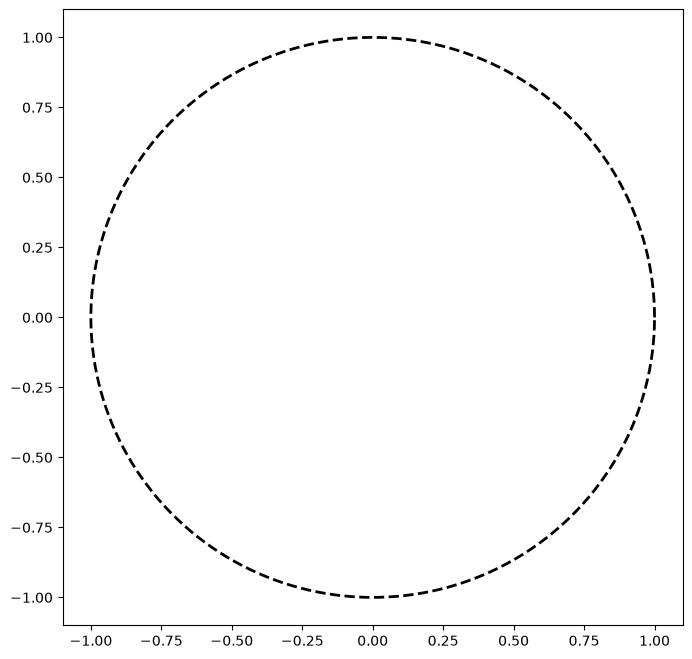

In [47]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [39]:
m_arnoldi = 80
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 175.50ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 188.07ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 238.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 292.47ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 356.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 456.06ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 190.13ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 232.42ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 288.22ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 348.58ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 443.59ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 552.75ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 200.93ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 244.05ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 316.39ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 403.45ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 493.14ms ◆ remaining 0.00ms
|██████████|

In [35]:
m_arnoldi_new = 80
Q_new, H_new, mu_list_new = solver.arnoldi_hessenberg(
    x0, 
    solver.chebyshev_filter, 
    m_new = m_arnoldi_new,
    m_old = m_arnoldi,
    Q_old = Q,
    H_old = H,
    mu_list_old = mu_list,
    )

|██████████| 100.0% ◆ elapsed 500.79ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 536.53ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 637.70ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 709.77ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 758.20ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 798.30ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 482.25ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 553.01ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 655.15ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 721.31ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 769.69ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 755.47ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 451.53ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 521.93ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 646.21ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 718.24ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 761.73ms ◆ remaining 0.00ms
|██████████| 1

In [13]:
m_arnoldi_new_new = 60
Q_new_new, H_new_new, mu_list_new_new = solver.arnoldi_hessenberg(
    x0, 
    solver.chebyshev_filter, 
    m_new = m_arnoldi_new_new,
    m_old = m_arnoldi_new,
    Q_old = Q_new,
    H_old = H_new,
    mu_list_old = mu_list_new,
    )

10
10


|██████████| 100.0% ◆ elapsed 220.76ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 241.01ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 297.04ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 400.56ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 480.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 540.19ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 204.05ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 247.73ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 295.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 411.34ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 488.07ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 550.14ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 213.43ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 262.84ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 354.30ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 437.35ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 511.61ms ◆ 

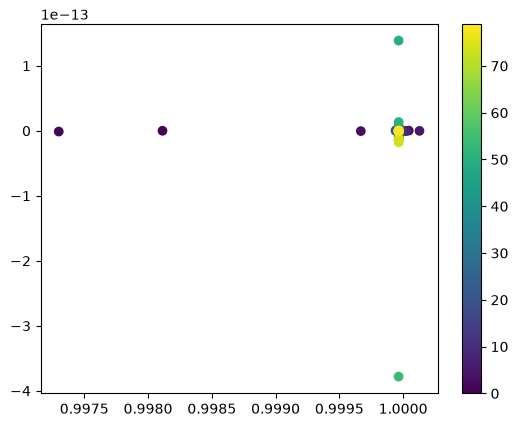

In [40]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

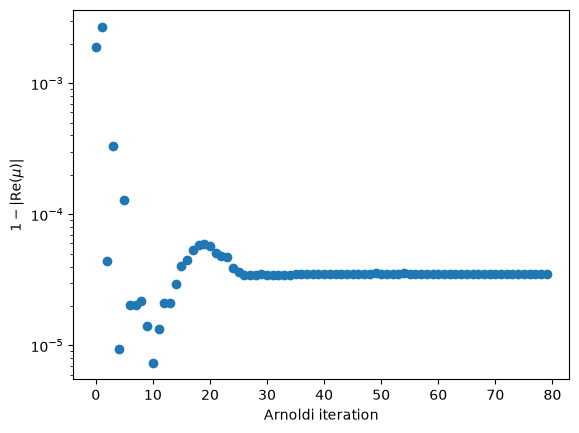

In [41]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [42]:
solver.rate_from_mu(mu_list[-1])

Array(0.00014148-6.58851531e-16j, dtype=complex128)

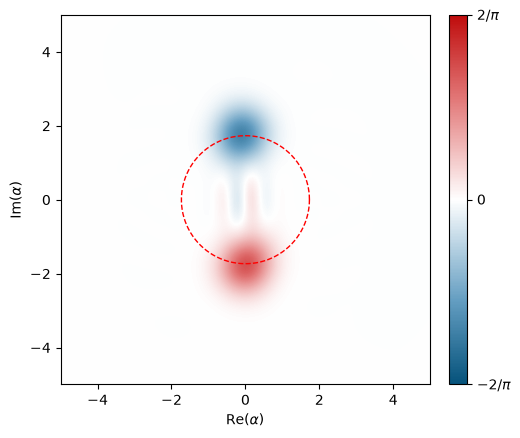

In [44]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [45]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 199.12ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99996491+5.62622129e-16j, dtype=complex128),
 'res_rel': Array(2.34726534e-05, dtype=float64),
 'rate_RQ': Array(0.0001415-2.26901737e-15j, dtype=complex128)}

In [46]:
eps_p = .4
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 190.93ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 255.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 318.89ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 430.55ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 473.71ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 459.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 459.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 461.57ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 457.88ms ◆ remaining 0.00ms
|███████

In [48]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.07950255224935798+2.77516878911805e-15j),
 'semi_re': np.float64(0.9154016191818142),
 'semi_im': np.complex128(0.8898401057444592+8.637546546130738e-16j),
 'ritz_bitflip': np.complex128(0.9999041714311722+3.9968028886505635e-15j),
 'vertex_x': np.complex128(0.9949041714311722+3.9968028886505635e-15j),
 'margin': 0.005,
 'max_level': 0.995,
 'ritz_vals_enc': array([ 0.96072292+1.38218916e-01j,  0.92170637+2.48606371e-01j,
         0.8820929 +2.61073746e-01j,  0.96072292-1.38218916e-01j,
         0.87128741+1.17050945e-01j,  0.88020119-1.03754411e-10j,
         0.87128741-1.17050945e-01j,  0.92170637-2.48606371e-01j,
         0.8820929 -2.61073746e-01j,  0.82068489-3.67835010e-01j,
         0.75303967-4.53841890e-01j,  0.74231856-5.06176565e-01j,
         0.67542322-5.58209472e-01j,  0.58693188-6.48004640e-01j,
         0.49256724-7.09233394e-01j,  0.36947177-7.56229639e-01j,
         0.34561466-7.70785052e-01j,  0.23115538-8.41599242e-01j,
         0.820684

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


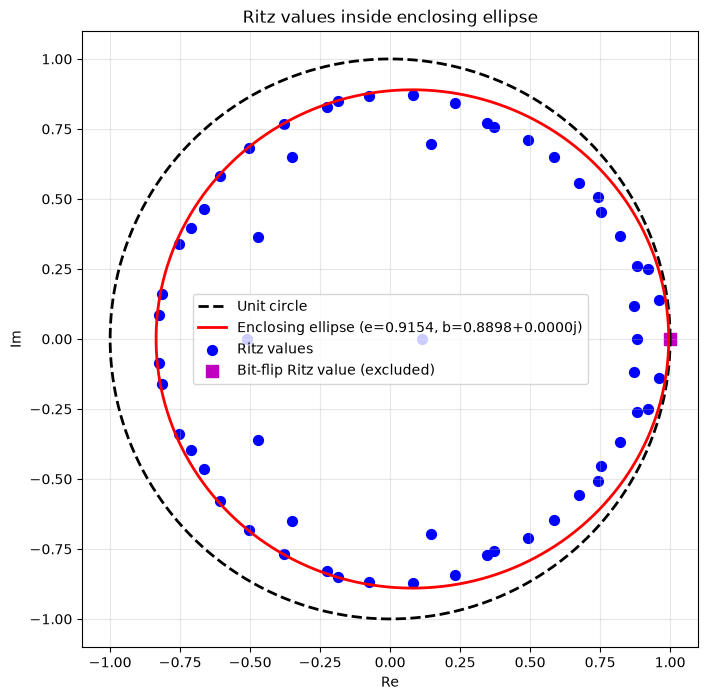

In [49]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [50]:
m_arnoldi = 80
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 200.14ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 219.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 314.94ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 417.51ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 532.95ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 625.62ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 221.74ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 282.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 387.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 511.26ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 615.61ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 689.67ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 207.52ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 267.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 341.31ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 488.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 606.50ms ◆ remaining 0.00ms
|██████████| 

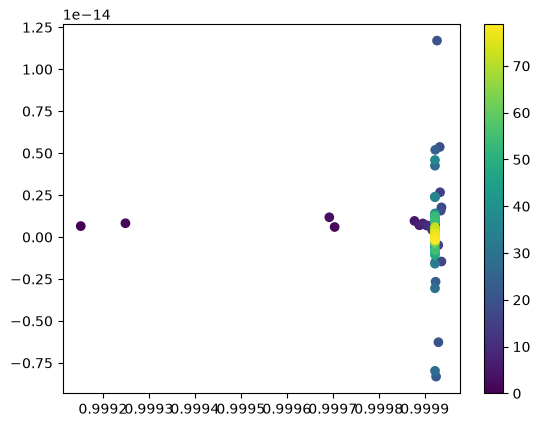

In [53]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

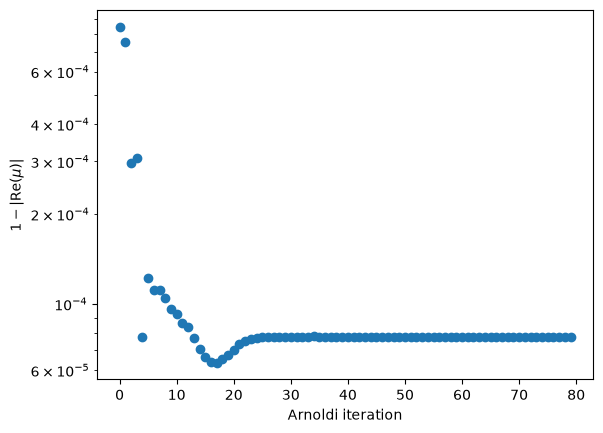

In [54]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [55]:
solver.rate_from_mu(mu_list[-1])

Array(0.00031347+6.90457225e-16j, dtype=complex128)

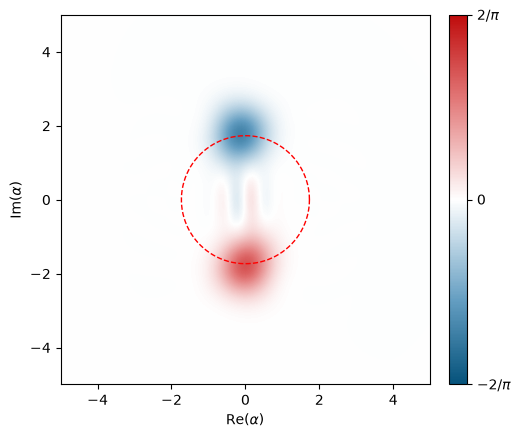

In [56]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [57]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 190.71ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99992227-4.66464179e-17j, dtype=complex128),
 'res_rel': Array(2.60209937e-06, dtype=float64),
 'rate_RQ': Array(0.0003135+1.88129903e-16j, dtype=complex128)}

In [58]:
eps_p = .6
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 197.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 252.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 315.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 389.89ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 428.12ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 416.38ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 395.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 389.72ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 382.19ms ◆ remaining 0.00ms
|█████████

In [59]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.05241032472535068+1.9280553240004563e-17j),
 'semi_re': np.float64(0.9423120177023697),
 'semi_im': np.complex128(0.897015630584875+1.7168724336859844e-17j),
 'ritz_bitflip': np.complex128(0.9997223424277204+2.8132719654576e-17j),
 'vertex_x': np.complex128(0.9947223424277204+2.8132719654576e-17j),
 'margin': 0.005,
 'max_level': 0.9949999999999999,
 'ritz_vals_enc': array([-0.08369372+8.73025141e-01j,  0.11885146+8.66261848e-01j,
        -0.00260059+8.43453483e-01j,  0.19642915+8.40952947e-01j,
         0.36320008+8.02105132e-01j,  0.47218496+7.55840426e-01j,
         0.27436899+7.42266335e-01j,  0.50880569+6.83847405e-01j,
         0.64081007+6.15925926e-01j,  0.71615192+5.55997218e-01j,
         0.84172021+4.33790621e-01j,  0.70319642+4.54281286e-01j,
         0.8225443 +3.53394855e-01j,  0.88185029+2.93598703e-01j,
         0.95767423+1.74420486e-01j,  0.84210689+1.63875730e-01j,
         0.95835522+1.17270112e-14j,  0.95767423-1.74420486e-01j,
        

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


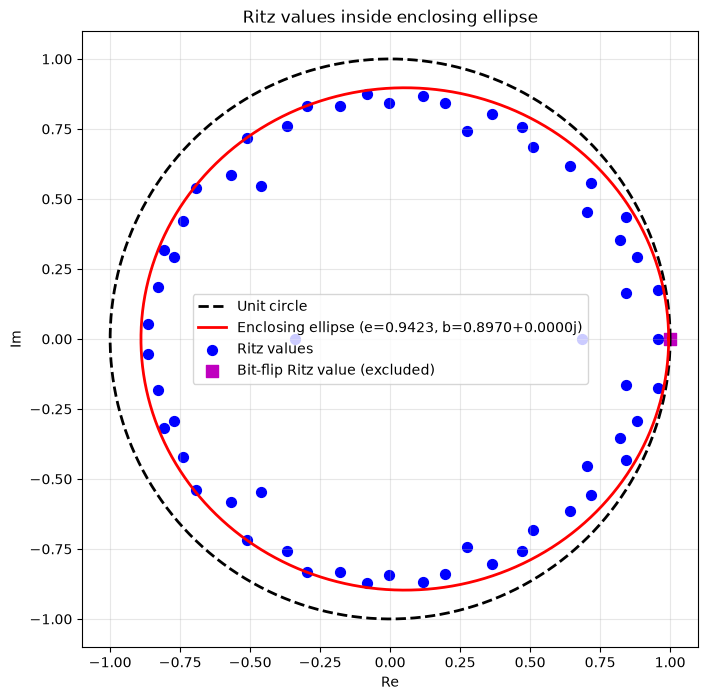

In [60]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [61]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 197.17ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 226.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 295.35ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 405.38ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 514.72ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 607.43ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 229.86ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 285.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 396.70ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 514.44ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 617.69ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 672.40ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 240.66ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 292.35ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 395.51ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 507.99ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 604.83ms ◆ remaining 0.00ms
|██████████| 1

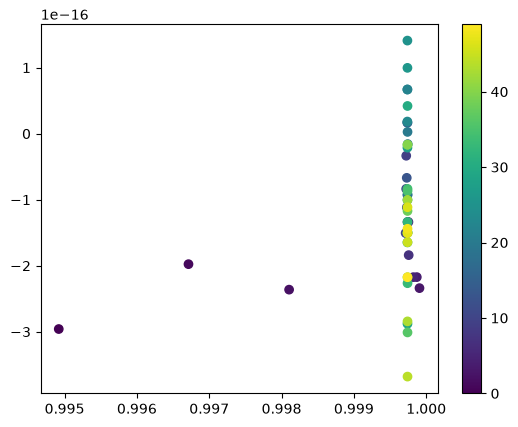

In [62]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

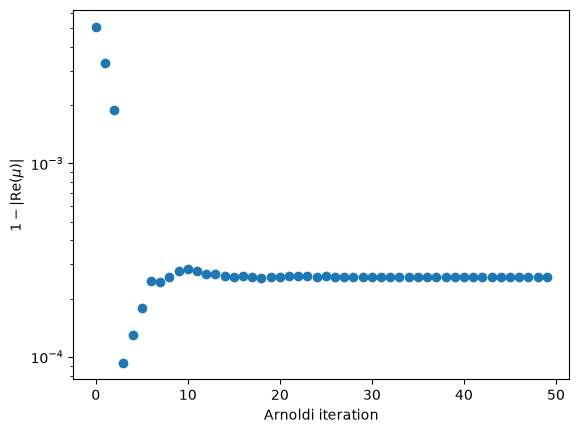

In [63]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [67]:
solver.rate_from_mu(mu_list[-1])

Array(0.00104346+8.77021381e-16j, dtype=complex128)

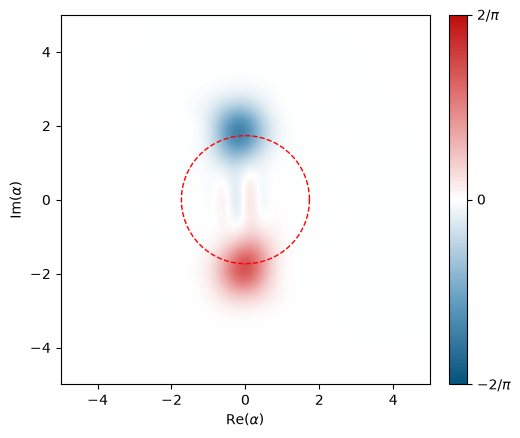

In [68]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [69]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 232.75ms ◆ remaining 0.00ms 


{'mu_RQ': Array(0.99974129+5.70081748e-17j, dtype=complex128),
 'res_rel': Array(2.26441778e-06, dtype=float64),
 'rate_RQ': Array(0.00104347-2.29961579e-16j, dtype=complex128)}

In [70]:
eps_p = .7
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 226.34ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 310.23ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 345.40ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 422.99ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 444.82ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 447.04ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 439.09ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 439.31ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 437.47ms ◆ remaining 0.00ms
|████████

In [71]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.05979628318706354+7.50918479759923e-17j),
 'semi_re': np.float64(0.9347740041518025),
 'semi_im': np.complex128(0.9051131098748603+4.4455275205559544e-17j),
 'ritz_bitflip': np.complex128(0.999570287338866+1.0916989389382444e-16j),
 'vertex_x': np.complex128(0.994570287338866+1.0916989389382444e-16j),
 'margin': 0.005,
 'max_level': 0.995,
 'ritz_vals_enc': array([-7.72346706e-01+4.04078323e-01j, -7.78529257e-01+3.38683002e-01j,
        -8.30528279e-01+1.83795536e-01j, -8.51667022e-01+9.73662183e-02j,
        -8.61020525e-01-9.50996769e-16j, -8.51667022e-01-9.73662183e-02j,
        -8.30528279e-01-1.83795536e-01j, -7.78529257e-01-3.38683002e-01j,
        -7.72346706e-01-4.04078323e-01j, -6.92558819e-01+4.58729801e-01j,
        -6.75154776e-01+1.21865674e-13j, -6.92558819e-01-4.58729801e-01j,
        -6.02660097e-01-6.33235329e-01j, -5.36557784e-01-6.59010641e-01j,
        -3.81501491e-01-7.95331658e-01j, -4.78367741e-01-5.78737035e-01j,
        -3.61450372e

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


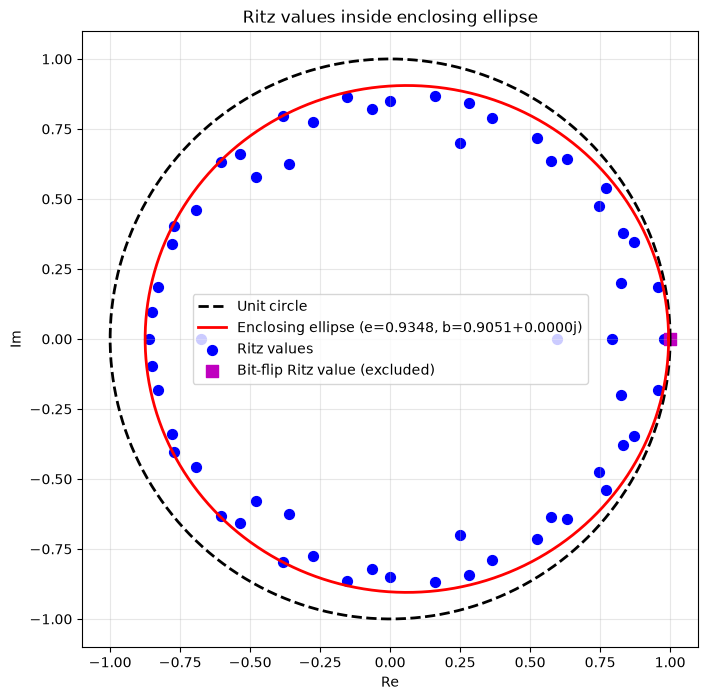

In [72]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [73]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 233.64ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 255.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 372.03ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 523.38ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 651.94ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 724.11ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 267.54ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 323.55ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 461.92ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 579.59ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 660.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 729.44ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 258.05ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 330.84ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 466.85ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 590.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 681.68ms ◆ remaining 0.00ms
|██████████| 

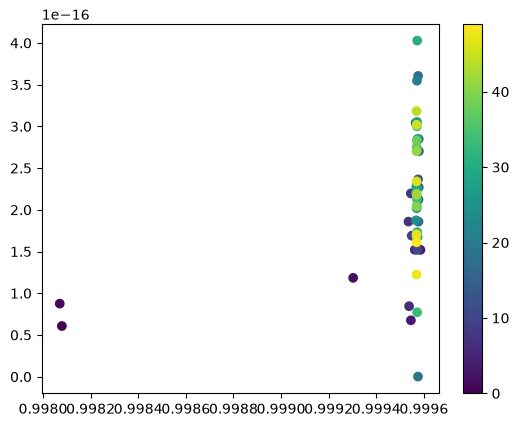

In [79]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

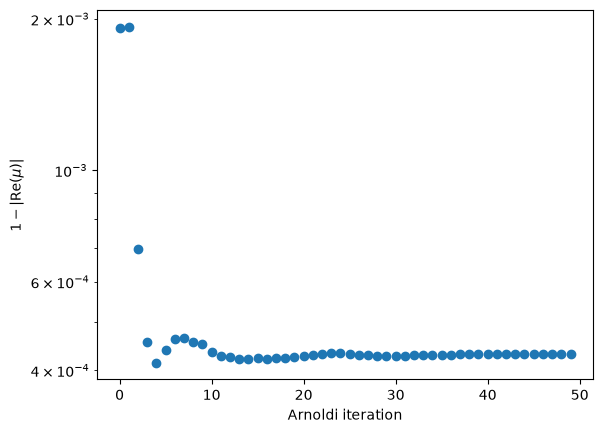

In [80]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [81]:
solver.rate_from_mu(mu_list[-1])

Array(0.00173749-6.49974835e-16j, dtype=complex128)

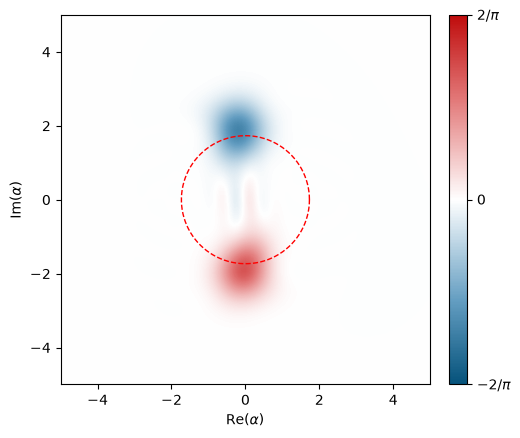

In [82]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [83]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 247.06ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99956924+8.89889109e-17j, dtype=complex128),
 'res_rel': Array(3.72163761e-05, dtype=float64),
 'rate_RQ': Array(0.00173753-3.5902838e-16j, dtype=complex128)}

In [84]:
eps_p = .9
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 239.98ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 322.64ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 344.55ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 344.61ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 345.50ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 348.65ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 346.26ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 343.46ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 346.41ms ◆ remaining 0.00ms
|████████

In [85]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.041398317098610526-2.5367566501178477e-17j),
 'semi_re': np.float64(0.9525536996879803),
 'semi_im': np.complex128(0.8923627175554101-4.227438449603001e-18j),
 'ritz_bitflip': np.complex128(0.9989520167865908-3.720452343056184e-17j),
 'vertex_x': np.complex128(0.9939520167865908-3.720452343056184e-17j),
 'margin': 0.005,
 'max_level': 0.9950000000000002,
 'ritz_vals_enc': array([ 0.56005895-7.43917846e-01j,  0.26594116-8.41617777e-01j,
         0.39477307-8.10995965e-01j,  0.37083006-7.63411985e-01j,
         0.56761064-6.68376177e-01j,  0.71571316-5.58251161e-01j,
         0.63795278-5.49124802e-01j,  0.73980592-4.82315397e-01j,
         0.87917335-3.52400934e-01j,  0.95715333-1.85388889e-01j,
         0.77550645-3.25126729e-01j,  0.95715333+1.85388889e-01j,
         0.96409528+3.39833224e-15j,  0.86410408-1.44699141e-01j,
         0.87917335+3.52400934e-01j,  0.86410408+1.44699141e-01j,
         0.75556865+2.04547068e-14j,  0.77550645+3.25126729e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


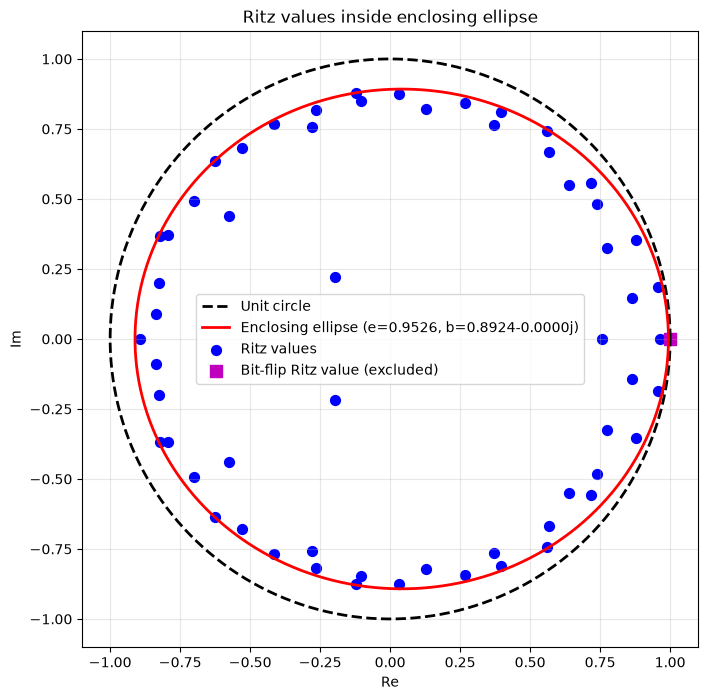

In [86]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [87]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 251.95ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 259.15ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 336.55ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 481.47ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 589.14ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 634.65ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 261.93ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 319.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 430.99ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 538.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 609.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 652.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 267.57ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 339.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 470.04ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 575.01ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 652.71ms ◆ remaining 0.00ms
|██████████| 1

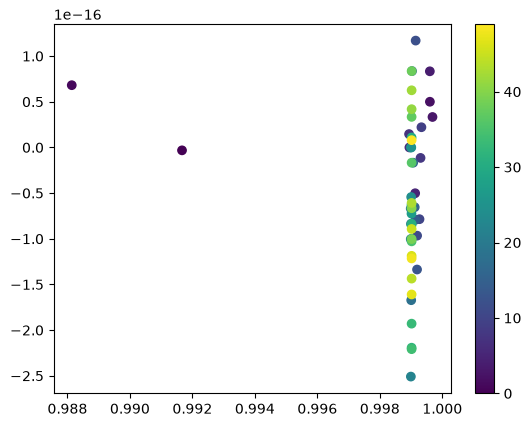

In [88]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

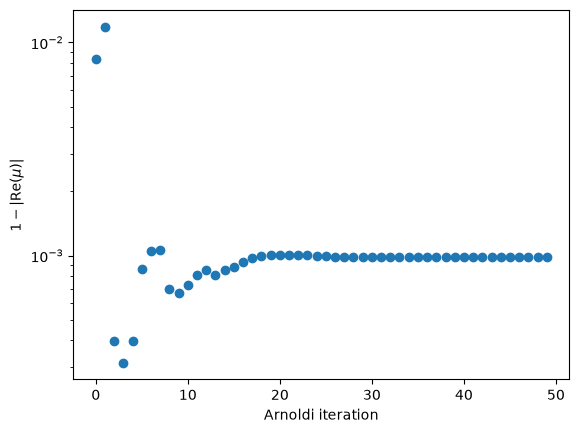

In [89]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [90]:
solver.rate_from_mu(mu_list[-1])

Array(0.00396295-3.20839155e-17j, dtype=complex128)

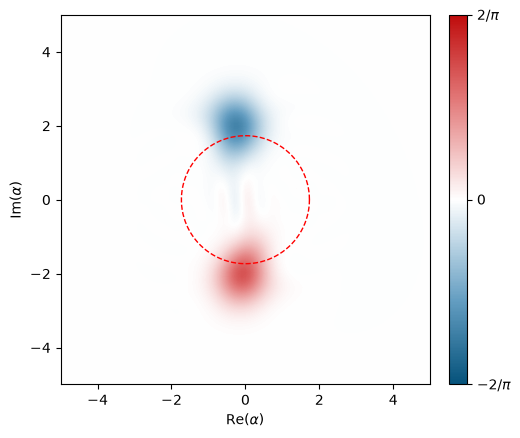

In [91]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [92]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 276.92ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99901785-1.1834706e-16j, dtype=complex128),
 'res_rel': Array(3.75720498e-05, dtype=float64),
 'rate_RQ': Array(0.00396276+4.7773823e-16j, dtype=complex128)}

In [93]:
eps_p = 1
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 262.48ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 326.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 326.59ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 327.12ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 325.42ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 323.22ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 339.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 324.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 317.12ms ◆ remaining 0.00ms
|█████████

In [94]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.04555807458956451-2.6672579548254703e-17j),
 'semi_re': np.float64(0.9479060228515338),
 'semi_im': np.complex128(0.9051396591297217+1.2670798370952034e-17j),
 'ritz_bitflip': np.complex128(0.9984640974410983-3.903256699631124e-17j),
 'vertex_x': np.complex128(0.9934640974410983-3.903256699631124e-17j),
 'margin': 0.005,
 'max_level': 0.9949999999999999,
 'ritz_vals_enc': array([-0.77496747-4.47837397e-01j, -0.82273306-3.19460757e-01j,
        -0.87151838-1.97534024e-01j, -0.88943978-9.43877079e-02j,
        -0.76608978-3.08389900e-01j, -0.88943978+9.43877079e-02j,
        -0.87151838+1.97534024e-01j, -0.81637479+5.40800980e-15j,
        -0.82273306+3.19460757e-01j, -0.77496747+4.47837397e-01j,
        -0.76608978+3.08389900e-01j, -0.66874922+5.31561819e-01j,
        -0.57697738+6.64223998e-01j, -0.54017034+6.44376197e-01j,
        -0.41846937+7.49968425e-01j, -0.29965189+8.28358828e-01j,
        -0.26723033+8.27613196e-01j, -0.11412175+8.61074812e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


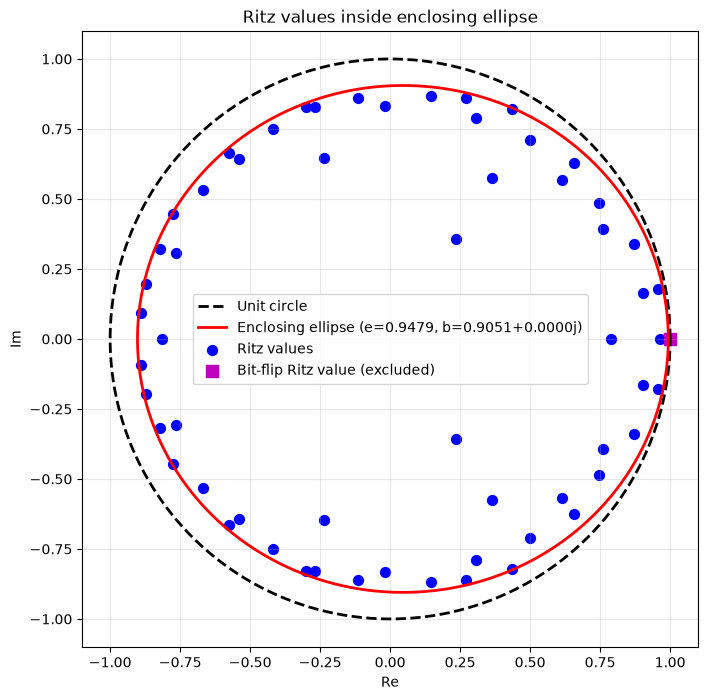

In [95]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [96]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 257.08ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 270.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 374.33ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 490.80ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 566.93ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 625.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 287.56ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 360.06ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 472.07ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 563.54ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 622.33ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 663.99ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 269.57ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 316.67ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 451.28ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 550.19ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 612.01ms ◆ remaining 0.00ms
|██████████| 1

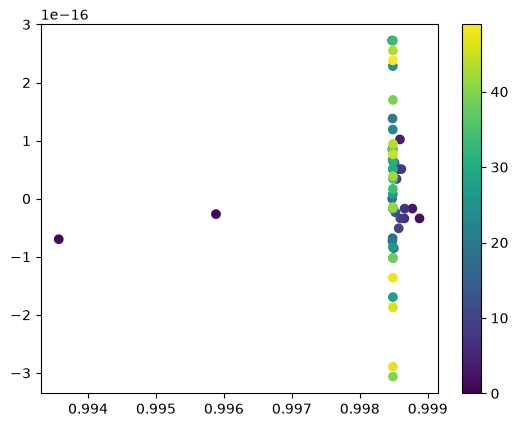

In [102]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

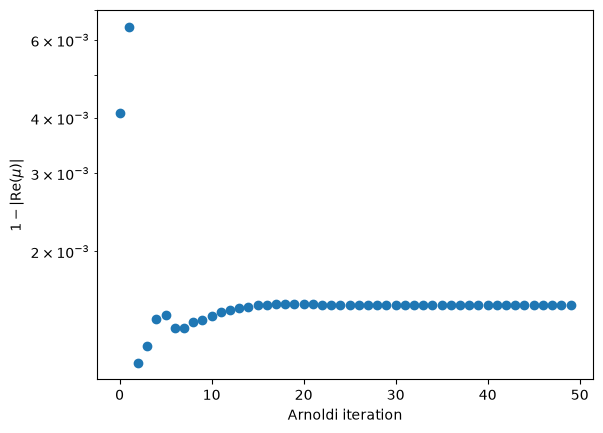

In [98]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [103]:
solver.rate_from_mu(mu_list[-1])

Array(0.00610352-9.61799085e-16j, dtype=complex128)

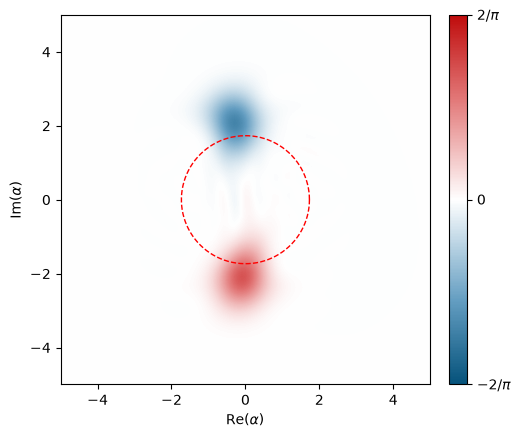

In [104]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [105]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 269.90ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99848766+1.4418689e-16j, dtype=complex128),
 'res_rel': Array(4.0319881e-07, dtype=float64),
 'rate_RQ': Array(0.00610355-5.82356388e-16j, dtype=complex128)}

In [106]:
eps_p = 1.1
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 287.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 306.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 290.96ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 287.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 293.08ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 296.65ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 299.60ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 302.75ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 315.19ms ◆ remaining 0.00ms
|█████████

In [107]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.045861788195439956-5.513771411893235e-16j),
 'semi_re': np.float64(0.9458566328745563),
 'semi_im': np.complex128(0.9163724189297237+1.6690993859571174e-16j),
 'ritz_bitflip': np.complex128(0.9967184210699963-8.062932737655141e-16j),
 'vertex_x': np.complex128(0.9917184210699963-8.062932737655141e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999999,
 'ritz_vals_enc': array([ 0.31584282-8.75855792e-01j,  0.15589429-8.84322091e-01j,
         0.04331435-8.70553334e-01j,  0.25804077-8.14480203e-01j,
         0.19737789-7.81881814e-01j,  0.45402722-7.36302248e-01j,
         0.60027876-6.74003065e-01j,  0.55076535-6.36494660e-01j,
         0.73510198-4.81180956e-01j,  0.59669594-4.86794282e-01j,
         0.86896756-3.33088887e-01j,  0.71005999-4.02193279e-01j,
         0.95109186-1.70056092e-01j,  0.92182403-1.66801542e-01j,
         0.94189032+2.57193521e-15j,  0.95109186+1.70056092e-01j,
         0.92182403+1.66801542e-01j,  0.71382961-1.15933492e-01j,
   

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


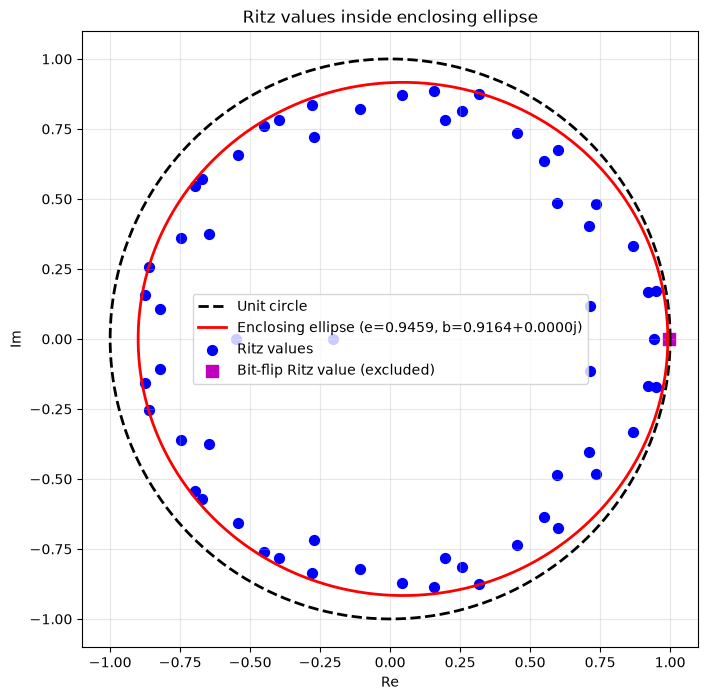

In [108]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [109]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

|██████████| 100.0% ◆ elapsed 269.97ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 311.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 434.64ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 534.24ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 607.56ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 674.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 286.45ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 352.49ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 468.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 556.55ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 666.23ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 698.24ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 294.41ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 384.49ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 504.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 602.91ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 623.83ms ◆ remaining 0.00ms
|██████████| 1

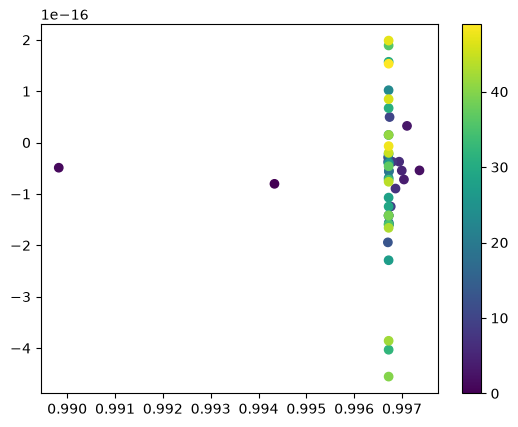

In [110]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

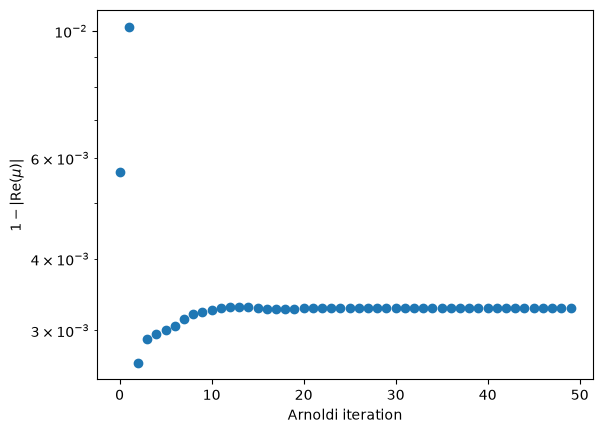

In [111]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [112]:
solver.rate_from_mu(mu_list[-1])

Array(0.0132496-6.21024083e-16j, dtype=complex128)

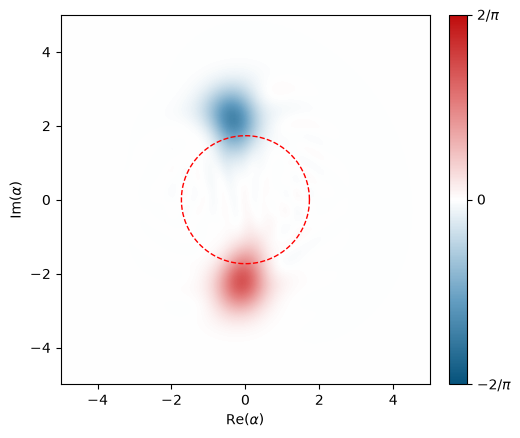

In [113]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [114]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 286.00ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99671992+1.69415841e-16j, dtype=complex128),
 'res_rel': Array(2.8175484e-06, dtype=float64),
 'rate_RQ': Array(0.01324963-6.85467155e-16j, dtype=complex128)}

In [115]:
eps_p = 1.2
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = eps_p)
solver = ChebAr(Ham_full, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=6)
x0 = x_ritz
Q0, H0, ritz_vals = solver.first_estimation(x0, m_arnoldi=60)


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 282.84ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 305.98ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 307.36ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 312.36ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 310.59ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 321.87ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 331.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 324.45ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 330.49ms ◆ remaining 0.00ms
|█████████

In [116]:
solver.setup_chebyshev(ritz_vals, margin=5e-3)

/home/tmalasda/dev/cheb_ar.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


{'center_a': np.complex128(0.042022688953662346+1.2806851232294293e-16j),
 'semi_re': np.float64(0.9440817164730906),
 'semi_im': np.complex128(0.9226185702581069-2.3700754304450917e-17j),
 'ritz_bitflip': np.complex128(0.9911044054267529+1.8727794889068248e-16j),
 'vertex_x': np.complex128(0.9861044054267529+1.8727794889068248e-16j),
 'margin': 0.005,
 'max_level': 0.9950000000000002,
 'ritz_vals_enc': array([-0.7772269 +4.31733306e-01j, -0.8159962 +3.56758301e-01j,
        -0.89414921+8.59780347e-02j, -0.89414921-8.59780347e-02j,
        -0.79864594+2.23907529e-01j, -0.80027575+1.03846473e-01j,
        -0.80027575-1.03846473e-01j, -0.79864594-2.23907529e-01j,
        -0.8159962 -3.56758301e-01j, -0.7772269 -4.31733306e-01j,
        -0.64617867+4.67625256e-01j, -0.62455518+5.47905909e-01j,
        -0.55505343+6.95785800e-01j, -0.49134931+7.33104515e-01j,
        -0.46884688+6.04038574e-01j, -0.3448659 +7.71811211e-01j,
        -0.28200808+7.82770762e-01j, -0.12360982+7.45055319e-01j,


/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


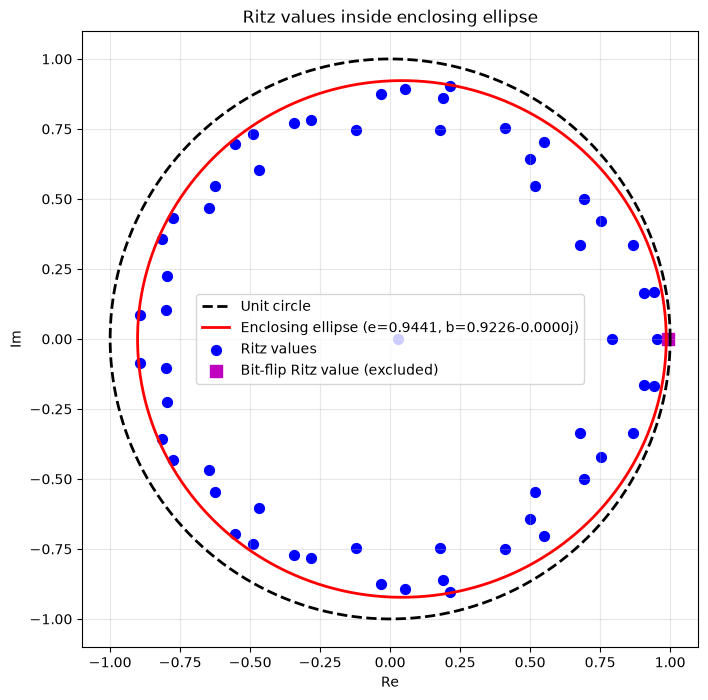

In [117]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [ ]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = True)

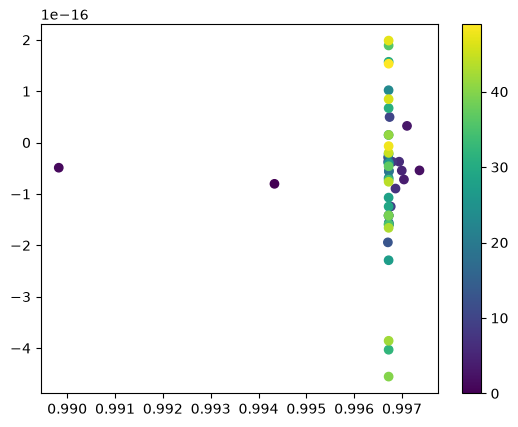

In [ ]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()

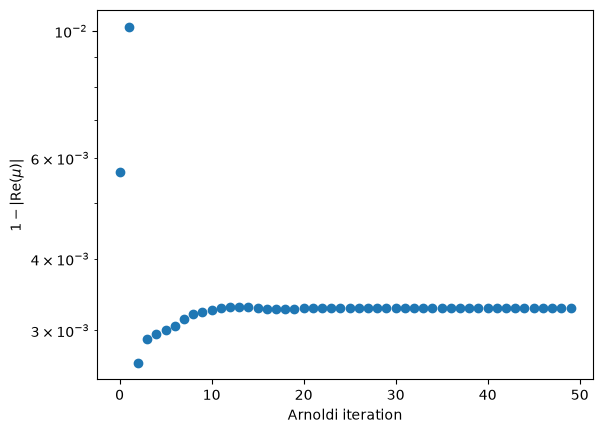

In [ ]:
plt.scatter(range(m_arnoldi), np.abs(1-np.real(mu_list)))
plt.xlabel("Arnoldi iteration")
plt.ylabel(r"$1-|\mathrm{Re}(\mu)|$")
plt.yscale("log")

In [ ]:
solver.rate_from_mu(mu_list[-1])

Array(0.0132496-6.21024083e-16j, dtype=complex128)

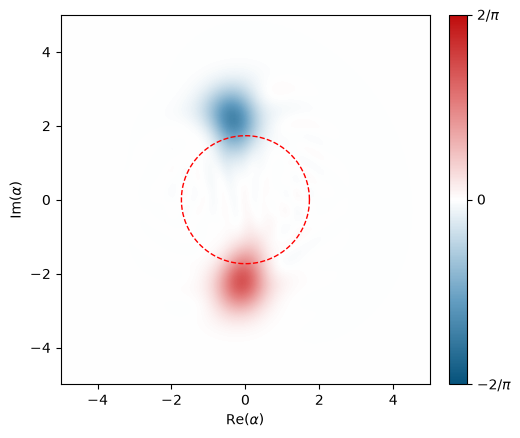

In [ ]:
x_ritz, rho_ritz = solver.ritz_vector(Q, H, m_arnoldi, target=mu_list[-1])
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_ritz,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()

In [ ]:
res = solver.residual_check(x_ritz)
res

|██████████| 100.0% ◆ elapsed 286.00ms ◆ remaining 0.00ms


{'mu_RQ': Array(0.99671992+1.69415841e-16j, dtype=complex128),
 'res_rel': Array(2.8175484e-06, dtype=float64),
 'rate_RQ': Array(0.01324963-6.85467155e-16j, dtype=complex128)}